#### NCSU GIS 714: Geospatial Computation and Simulations

## Exploring `r.sim.water` Diffusion Parameters on a Ditch-Berm Landform

This notebook creates a synthetic north-facing slope with a contour-parallel
ditch and berm, then runs *r.sim.water* across a grid of parameter values
to explore how the internal diffusion mechanism handles overflowing ditches.

**Parameters explored:**

- **hmax**: Threshold water depth (m) above which diffusion activates.
  Lower values trigger diffusion sooner.
- **hbeta**: Weighting factor for the "prevailing" flow direction.
  Controls how many previous cells are used to average flow direction
  when depth exceeds **hmax**.
- **halpha**: Diffusion increase constant. Controls how much diffusion
  amplifies when depth exceeds **hmax** (diffusion multiplied by halpha + 1).
- **diffusion_coeff**: Base water diffusion constant. Helps overcome
  small shallow pits and smooth flow over slope discontinuities.

See the [r.sim.water manual](https://grass.osgeo.org/grass-stable/manuals/r.sim.water.html) for details.

### Start GRASS GIS

In [6]:
import subprocess
import sys

# Ask GRASS GIS where its Python packages are.
# FOR WINDOWS:
# grass_call = "grass80"
# shell_setting = True
# FOR MAC/LINUX
grass_call = "grass"
shell_setting = False

sys.path.append(
    subprocess.check_output([grass_call, "--config", "python_path"], text=True, shell=shell_setting).strip()
)

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj

# Plotting
import numpy as np
import matplotlib.pyplot as plt

# Start GRASS Session
gj.init("../data", "nc_spm_08_grass7", "PERMANENT")

# Make a new mapset for this assignment
# gs.run_command("g.mapset", mapset="diffusion_demo", location="nc_spm_08_grass7", flags="c")

### 1. Define a synthetic computational region

We use a 200 m × 200 m region at 2 m resolution inside the NC SPM extent.
The coordinates are arbitrary — the elevation we build on top is entirely synthetic.

In [7]:
# Region corners (meters, NC State Plane). Size: 200 x 200 m at 2 m resolution.
REGION = dict(n=220200, s=220000, w=638000, e=638200, res=2)
gs.run_command("g.region", flags="p", **REGION)

projection: 99 (Lambert Conformal Conic)
zone:       0
datum:      nad83
ellipsoid:  a=6378137 es=0.006694380022900787
north:      220200
south:      220000
west:       638000
east:       638200
nsres:      2
ewres:      2
rows:       100
cols:       100
cells:      10000


### 2. Build the synthetic ditch-berm DEM

Construction:

- **Base plane**: 5% slope facing north (elevation decreases as `y()` increases).
- **Ditch**: east-west trench, 1 m deep, ~4 m wide, cut across mid-slope.
- **Berm**: east-west ridge, 0.5 m high, ~6 m wide, located just downslope (north) of the ditch.

The ditch and berm are contour-parallel, so flow arriving from the south has to either
fill the ditch or diffuse over the berm.

In [8]:
# Ditch and berm center latitudes (northing)
Y_DITCH = 220100.0   # mid-region
Y_BERM  = 220110.0   # ~10 m north (downslope) of ditch

# Base plane: 5% north-facing slope.
# In NC State Plane, y() increases northward, so to make the surface slope *down* toward
# the north we subtract 0.05 * (y() - y_south).
gs.mapcalc(f"base_plane = 100.0 - 0.05 * (y() - {REGION['s']})", overwrite=True)

# Ditch: 1 m deep trench, ~4 m wide, centered on Y_DITCH
gs.mapcalc(f"ditch = if(abs(y() - {Y_DITCH}) < 2.0, -1.0, 0.0)", overwrite=True)

# Berm: 0.5 m high ridge, ~6 m wide, centered on Y_BERM
gs.mapcalc(f"berm = if(abs(y() - {Y_BERM}) < 3.0, 0.5, 0.0)", overwrite=True)

# Final synthetic DEM
gs.mapcalc("elev_synth = base_plane + ditch + berm", overwrite=True)

# Gradient components for r.sim.water
gs.run_command(
    "r.slope.aspect",
    elevation="elev_synth",
    dx="dx_synth",
    dy="dy_synth",
    overwrite=True,
)

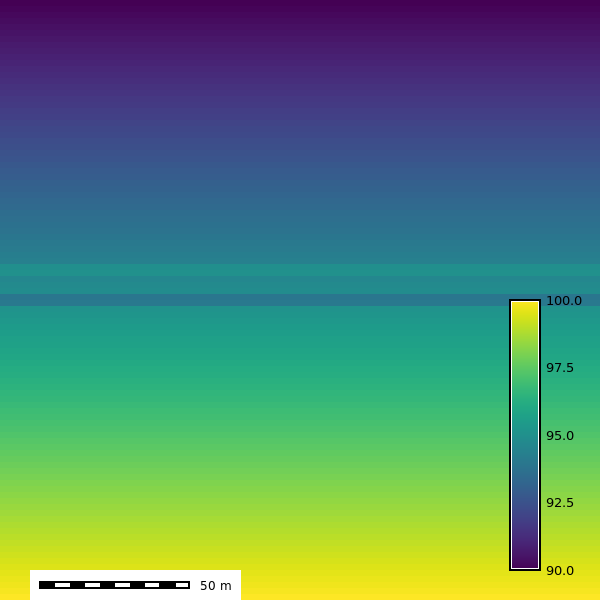

In [9]:
img = gj.Map(use_region=True)
img.d_rast(map="elev_synth")
img.d_legend(raster="elev_synth", at=(5, 50, 85, 90))
img.d_barscale(at=(5, 5))
img.show()

### 3. Cross-section helper

A north-south profile through the middle of the region makes the ditch-berm geometry
and subsequent water-depth patterns easy to read. We use `r.profile` to sample along
a vertical transect.

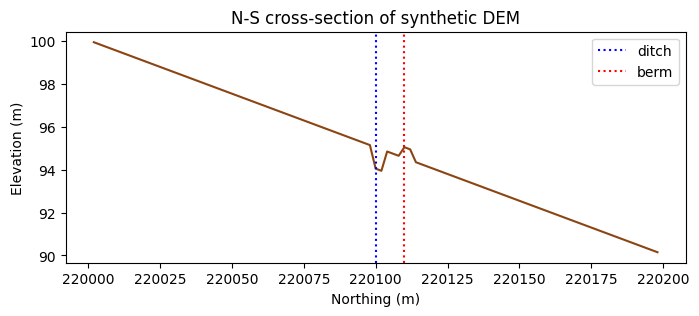

In [10]:
PROFILE_X = (REGION["w"] + REGION["e"]) / 2   # middle column
PROFILE_COORDS = f"{PROFILE_X},{REGION['s']},{PROFILE_X},{REGION['n']}"


def profile(raster):
    """Return (northing, value) arrays along a N-S transect for `raster`."""
    txt = gs.read_command(
        "r.profile",
        input=raster,
        coordinates=PROFILE_COORDS,
        null_value="nan",
        quiet=True,
    )
    dist, val = [], []
    for line in txt.strip().splitlines():
        parts = line.split()
        if len(parts) < 2:
            continue
        try:
            dist.append(float(parts[0]))
            val.append(float(parts[1]))
        except ValueError:
            val.append(np.nan)
    y = np.array(dist) + REGION["s"]
    return y, np.array(val)


# Sanity check: plot the DEM profile
y, z = profile("elev_synth")
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(y, z, color="saddlebrown")
ax.axvline(Y_DITCH, color="blue", linestyle=":", label="ditch")
ax.axvline(Y_BERM, color="red", linestyle=":", label="berm")
ax.set_xlabel("Northing (m)")
ax.set_ylabel("Elevation (m)")
ax.set_title("N-S cross-section of synthetic DEM")
ax.legend()
plt.show()

### 4. Baseline `r.sim.water` run

Run SIMWE with default diffusion parameters and moderate rainfall.
This gives us a reference depth pattern to compare all sweeps against.

In [11]:
# Shared r.sim.water kwargs
SIM_COMMON = dict(
    elevation="elev_synth",
    dx="dx_synth",
    dy="dy_synth",
    rain_value=100,      # mm/hr
    infil_value=0,
    man_value=0.05,
    nwalkers=50000,
    niterations=20,
    output_step=20,
    overwrite=True,
)

gs.run_command(
    "r.sim.water",
    depth="wdp_baseline",
    discharge="disch_baseline",
    **SIM_COMMON,
)

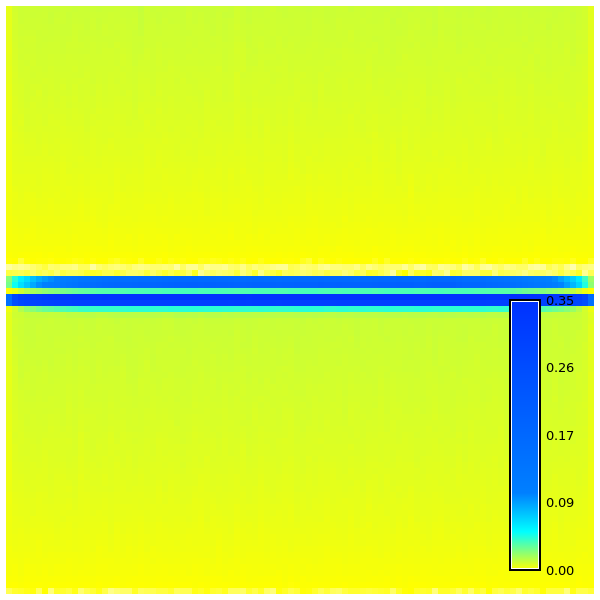

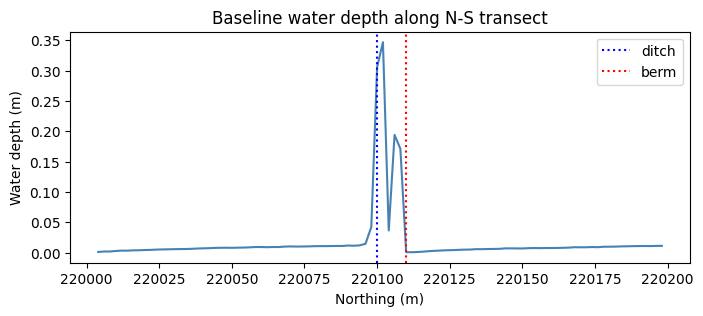

In [12]:
img = gj.Map(use_region=True)
img.d_rast(map="wdp_baseline")
img.d_legend(raster="wdp_baseline", at=(5, 50, 85, 90))
img.show()

# N-S cross-section of baseline depth
y, d = profile("wdp_baseline")
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(y, d, color="steelblue")
ax.axvline(Y_DITCH, color="blue", linestyle=":", label="ditch")
ax.axvline(Y_BERM, color="red", linestyle=":", label="berm")
ax.set_xlabel("Northing (m)")
ax.set_ylabel("Water depth (m)")
ax.set_title("Baseline water depth along N-S transect")
ax.legend()
plt.show()

### 5. Parameter sweeps

Helper function runs `r.sim.water` for a list of values of one parameter
(holding all others at their defaults) and returns the list of output depth rasters.

In [13]:
def sweep(param_name, values, tag):
    """Run r.sim.water once per value of `param_name`. Returns list of (value, depth_raster)."""
    results = []
    for v in values:
        depth_map = f"wdp_{tag}_{str(v).replace('.', 'p')}"
        disch_map = f"disch_{tag}_{str(v).replace('.', 'p')}"
        kwargs = dict(SIM_COMMON)
        kwargs[param_name] = v
        gs.run_command(
            "r.sim.water",
            depth=depth_map,
            discharge=disch_map,
            **kwargs,
        )
        results.append((v, depth_map))
    return results


def plot_sweep(results, param_name):
    """Overlay N-S depth profiles for each run in `results`."""
    fig, ax = plt.subplots(figsize=(9, 4))
    for v, rmap in results:
        y, d = profile(rmap)
        ax.plot(y, d, label=f"{param_name}={v}")
    ax.axvline(Y_DITCH, color="blue", linestyle=":", alpha=0.5)
    ax.axvline(Y_BERM, color="red", linestyle=":", alpha=0.5)
    ax.set_xlabel("Northing (m)")
    ax.set_ylabel("Water depth (m)")
    ax.set_title(f"N-S depth cross-section: sweep of {param_name}")
    ax.legend()
    plt.show()


def render_sweep(results, param_name):
    """Render one static depth map per run."""
    for v, rmap in results:
        print(f"{param_name} = {v}")
        img = gj.Map(use_region=True, width=300, height=300)
        img.d_rast(map=rmap)
        img.d_legend(raster=rmap, at=(5, 50, 85, 90))
        img.show()

### 5a. Sweep `hmax`

`hmax` is the depth threshold above which the diffusion mechanism kicks in.
Lower values cause diffusion to activate in shallower water — we expect lower
`hmax` values to spread water more aggressively across the berm.

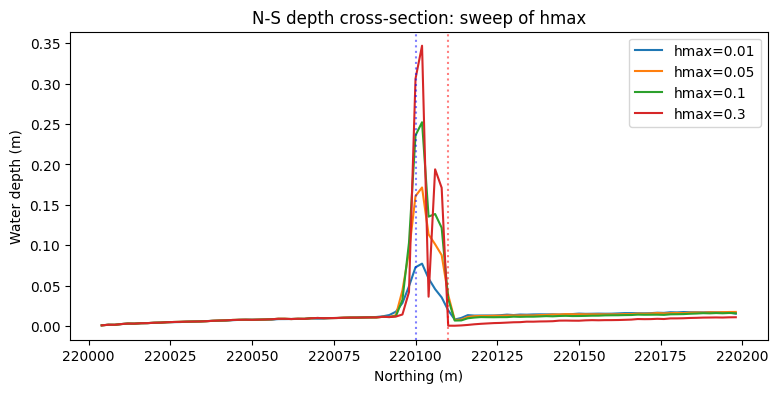

hmax = 0.01


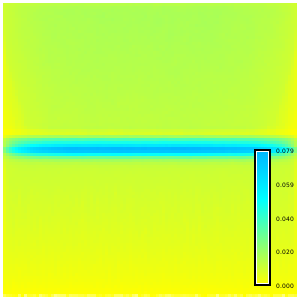

hmax = 0.05


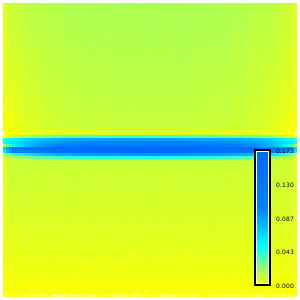

hmax = 0.1


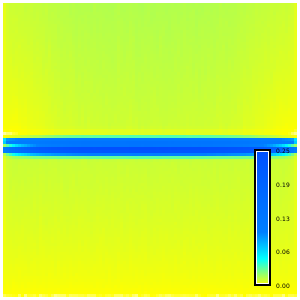

hmax = 0.3


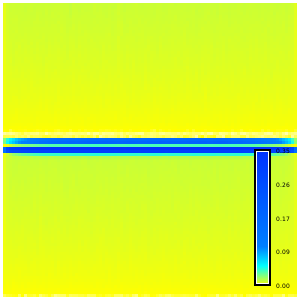

In [14]:
hmax_results = sweep("hmax", [0.01, 0.05, 0.1, 0.3], tag="hmax")
plot_sweep(hmax_results, "hmax")
render_sweep(hmax_results, "hmax")

### 5b. Sweep `hbeta`

`hbeta` controls how strongly the prevailing flow direction from previous cells
is weighted when depth exceeds `hmax`. Higher `hbeta` favors continuing along
established flow paths rather than following the immediate gradient.

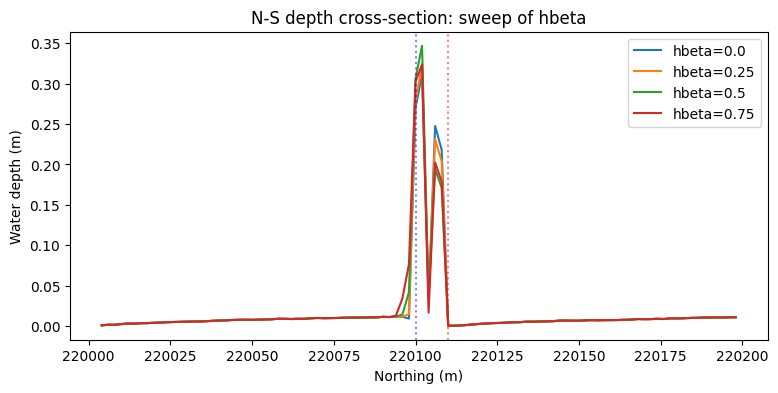

hbeta = 0.0


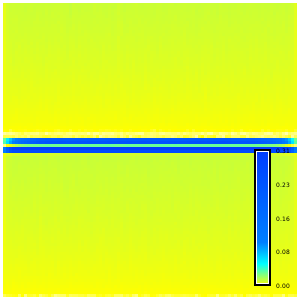

hbeta = 0.25


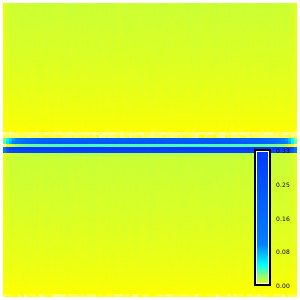

hbeta = 0.5


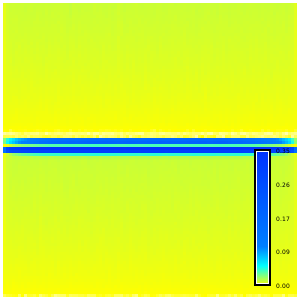

hbeta = 0.75


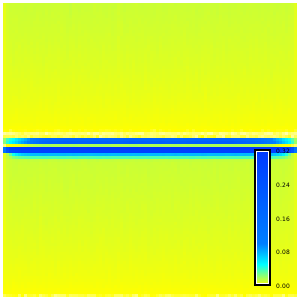

In [15]:
hbeta_results = sweep("hbeta", [0.0, 0.25, 0.5, 0.75], tag="hbeta")
plot_sweep(hbeta_results, "hbeta")
render_sweep(hbeta_results, "hbeta")

### 5c. Sweep `halpha`

`halpha` amplifies diffusion once depth exceeds `hmax` (effective diffusion scales
with `halpha + 1`). Higher values cause more spreading of overflow water.

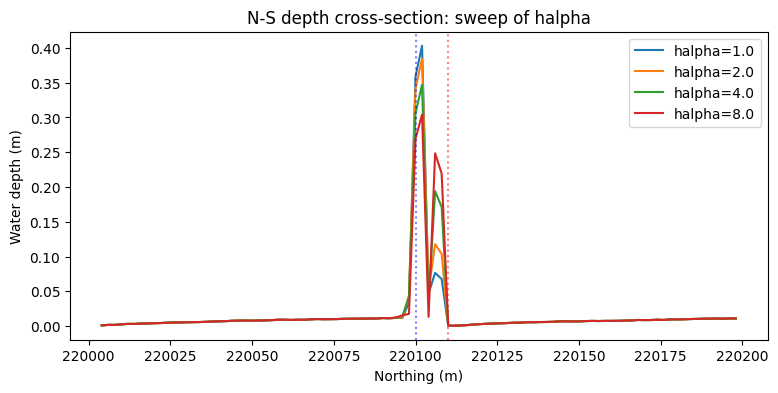

halpha = 1.0


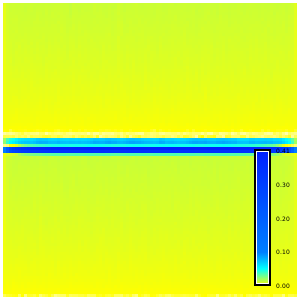

halpha = 2.0


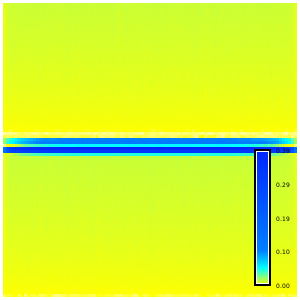

halpha = 4.0


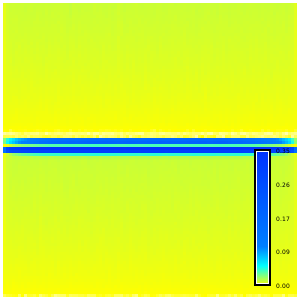

halpha = 8.0


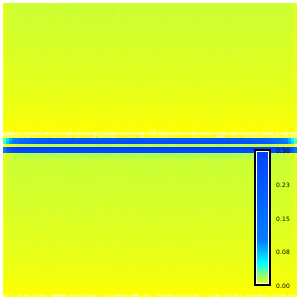

In [16]:
halpha_results = sweep("halpha", [1.0, 2.0, 4.0, 8.0], tag="halpha")
plot_sweep(halpha_results, "halpha")
render_sweep(halpha_results, "halpha")

### 5d. Sweep `diffusion_coeff`

The base diffusion coefficient operates everywhere (not just above `hmax`).
It helps water escape small shallow pits and smooths flow over slope
discontinuities such as the ditch-berm pair.

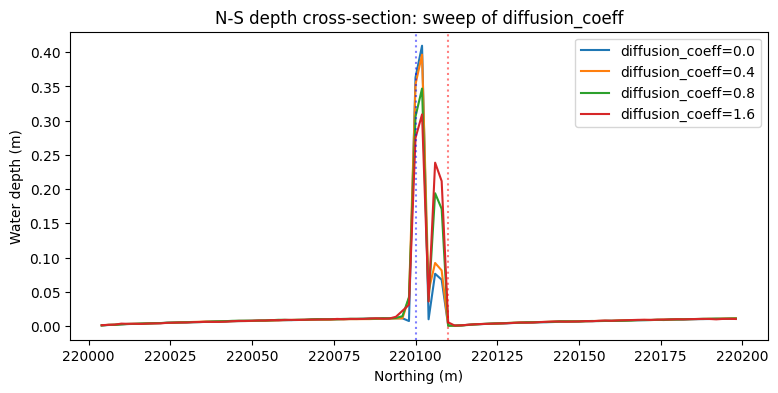

diffusion_coeff = 0.0


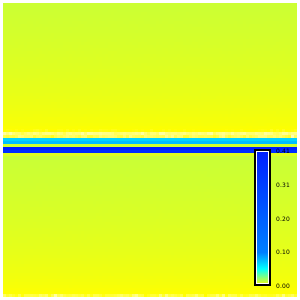

diffusion_coeff = 0.4


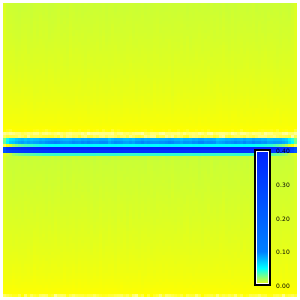

diffusion_coeff = 0.8


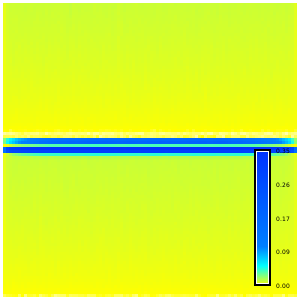

diffusion_coeff = 1.6


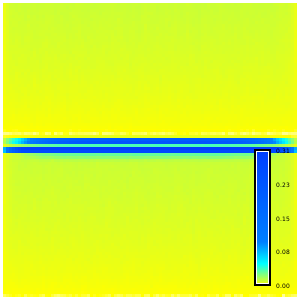

In [17]:
diff_results = sweep("diffusion_coeff", [0.0, 0.4, 0.8, 1.6], tag="diffcoef")
plot_sweep(diff_results, "diffusion_coeff")
render_sweep(diff_results, "diffusion_coeff")

### 6. Summary

#### *Question 1*

Which of the four parameters had the largest effect on water passing over the berm?
Describe the physical intuition for why.

#### *Question 2*

If you were simulating a real engineered drainage ditch (designed *not* to overflow),
which parameter settings would you choose, and why?

#### *Question 3*

Compare your `hmax` and `diffusion_coeff` sweeps. Both increase spreading, but in
different ways. Describe the qualitative difference between the two sweeps.

### Additional Information
* [r.sim.water manual](https://grass.osgeo.org/grass-stable/manuals/r.sim.water.html)
* [Course website](https://ncsu-geoforall-lab.github.io/geospatial-simulations-course/)
* License: 2026 [CC BY-SA](https://creativecommons.org/licenses/by-sa/4.0/)
* [NCSU GeoForAll Lab](https://geospatial.ncsu.edu/geoforall/)